In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

### 데이터베이스 생성

In [2]:
conn = sqlite3.connect('olist.db')

In [3]:
csv_files = [
    'data/customers.csv',
    'data/orders.csv',
    'data/order_items.csv',
    'data/products.csv',
    'data/sellers.csv',
    'data/order_payments.csv',
    'data/order_reviews.csv',
    'data/geolocation.csv',
    'data/product_category_name_translation.csv'
]

for file in csv_files:
    table_name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_csv(file)
    df.to_sql(table_name, conn, if_exists='replace', index=False)

In [7]:
from IPython.display import Image

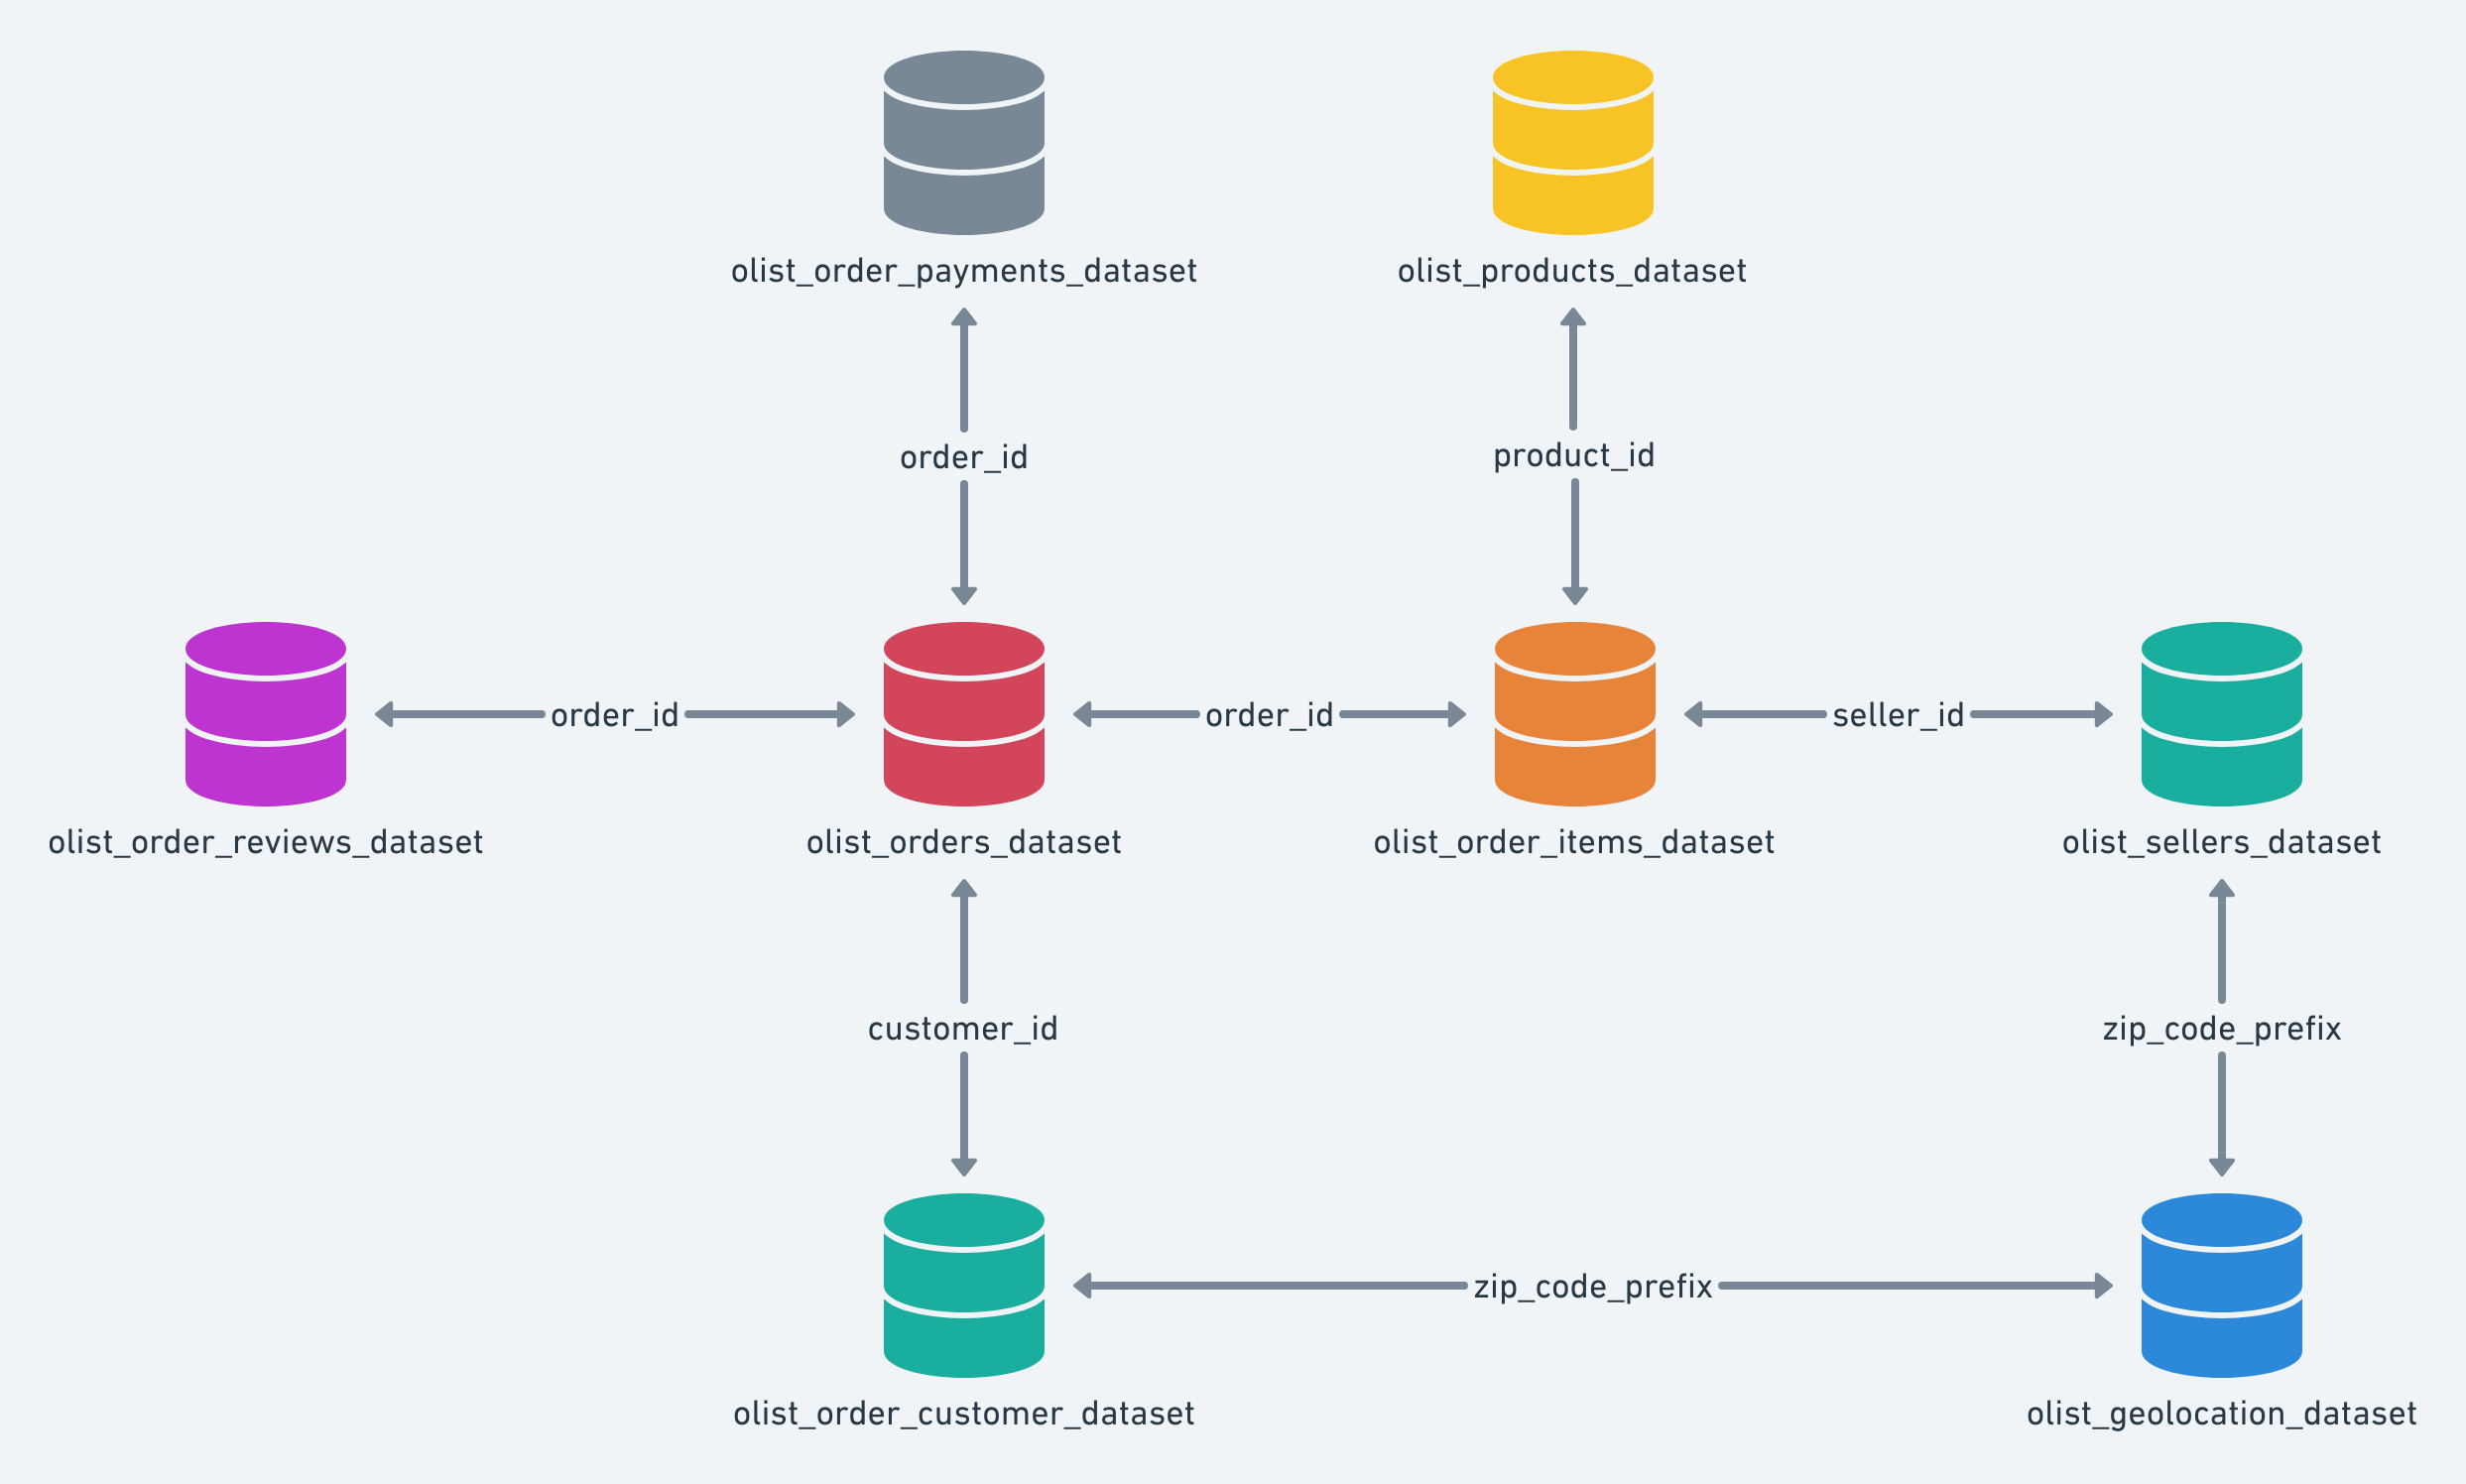

In [8]:
Image(filename='data/olist_erd.png',width=800)

### EDA

In [9]:
query = """
SELECT *
FROM ORDERS
"""

In [10]:
_df = pd.read_sql(query,conn)
_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [11]:
_df.order_status.value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [163]:
#_df[_df.order_status != 'delivered'].order_delivered_customer_date.fillna(0).astype(float)

In [13]:
orders = _df[
    ((_df.order_status != 'delivered') &
    (_df.order_delivered_customer_date.isna())) |
    (_df.order_status == 'delivered')
]
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


- 배송완료 상태가 아님에도 배송 완료일이 있는 데이터가 존재하여, 정확한 배송 지표 분석에 왜곡을 초래할 수 있으므로 해당 데이터를 제외

In [14]:
orders['order_id'].is_unique

True

In [15]:
orders[orders.order_status == 'delivered']['order_estimated_delivery_date']

0        2017-10-18 00:00:00
1        2018-08-13 00:00:00
2        2018-09-04 00:00:00
3        2017-12-15 00:00:00
4        2018-02-26 00:00:00
                ...         
99436    2017-03-28 00:00:00
99437    2018-03-02 00:00:00
99438    2017-09-27 00:00:00
99439    2018-02-15 00:00:00
99440    2018-04-03 00:00:00
Name: order_estimated_delivery_date, Length: 96478, dtype: object

In [16]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [17]:
# 데이터 타입 변경
orders=orders.assign(
    order_purchase_timestamp=lambda df:pd.to_datetime(df.order_purchase_timestamp),
    order_approved_at=lambda df:pd.to_datetime(df.order_approved_at),
    order_delivered_carrier_date=lambda df:pd.to_datetime(df.order_delivered_carrier_date),
    order_delivered_customer_date=lambda df:pd.to_datetime(df.order_delivered_customer_date),
    order_estimated_delivery_date=lambda df:pd.to_datetime(df.order_estimated_delivery_date)
)

In [18]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [19]:
orders=orders.assign(delay_days=lambda df:df[orders.order_status=='delivered']['order_delivered_customer_date'].dt.day-df[df.order_status=='delivered']['order_estimated_delivery_date'].dt.day)

In [20]:
pd.options.plotting.backend = 'plotly'

In [21]:
import plotly.io as pio

In [22]:
pio.templates.default = 'plotly_white'

In [23]:
# fig=orders.plot.hist(x='delay_days',title='실제 배송일과 예상 배송일의 차이')
# fig.update_layout(
#     title = {'x':0.5}
# )

In [24]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

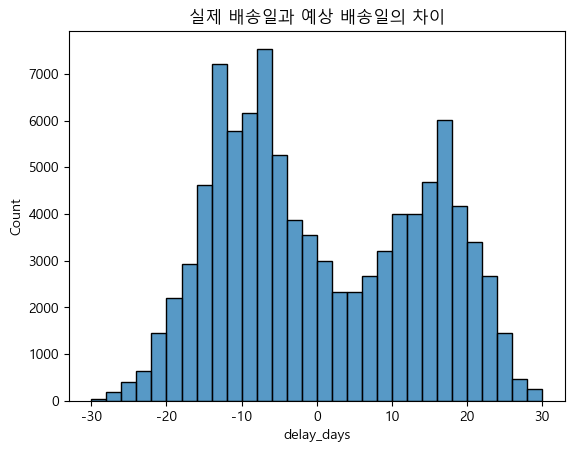

In [25]:
sns.histplot(data=orders, x='delay_days',bins=30)
plt.title('실제 배송일과 예상 배송일의 차이');

- 실제 배송일과 예상 배송일의 차이가 0을 기준으로 좌우로 넓게 퍼진 형태로 보임.
- 대부분의 고객이 예상 배송일 보다 훨씬 빠르게 또는 느리게 배송 받고 있음

In [26]:
orders.delay_days.describe()

count    96470.000000
mean         0.299181
std         13.371636
min        -30.000000
25%        -11.000000
50%         -3.000000
75%         13.000000
max         30.000000
Name: delay_days, dtype: float64

In [27]:
orders.delay_days

0        -8.0
1        -6.0
2        13.0
3       -13.0
4       -10.0
         ... 
99436   -11.0
99437    26.0
99438    -6.0
99439    10.0
99440    13.0
Name: delay_days, Length: 99435, dtype: float64

### 가설
$H_0$ : 실제 배송일과 예상 배송일의 차이가 없다.

$H_1$ : 실제 배송일과 예상 배송일 간 차이가 존재한다.

In [28]:
import scipy.stats as stats

In [29]:
stat,p_value = stats.ttest_1samp(orders.delay_days.dropna(),0)
p_value

3.69224300136437e-12

In [30]:
p_value < 0.05

True

- p_value < 0.05이므로 귀무가설을 기각. 따라서 실제 배송일과 예상 배송일간 통계적으로 유의한 차이가 존재

In [31]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,13.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0


In [32]:
orders=orders.drop(['order_approved_at','order_delivered_carrier_date'],axis=1)\
.assign(delivery_days=lambda df:(df.order_delivered_customer_date-df.order_purchase_timestamp).dt.days)

In [33]:
# (orders.order_delivered_customer_date-orders.order_purchase_timestamp).dt.days\
# .plot.hist(title='구매 후 배송시간(일)',nbins=30)

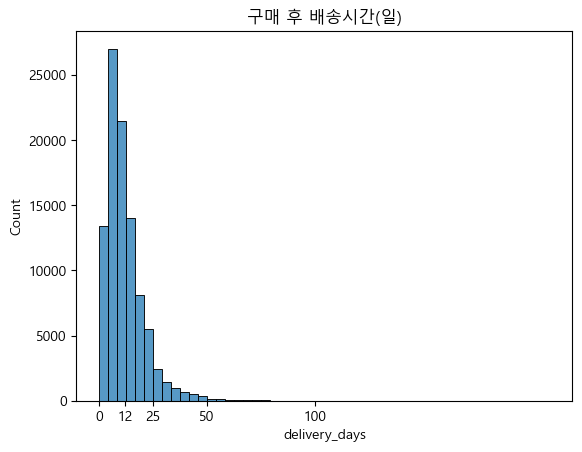

In [55]:
sns.histplot(data=orders, x='delivery_days',bins=50)
plt.title('구매 후 배송시간(일)')
plt.xticks([0,12,25,50,100]);

In [40]:
orders.delivery_days.describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

- 제품 구입 후 배송까지 평균적으로 12일 정도 소요
- 사분위수범위를 기준으로 이상치를 정의하여 25일 초과부터 배송지연으로 간주

In [76]:
order_delay = orders[orders.delivery_days > 25].order_id
order_delay.count()

6978

In [64]:
query="""
SELECT *
FROM ORDER_ITEMS
"""

In [65]:
order_item=pd.read_sql(query,conn)
order_item.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [66]:
query="""
SELECT *
FROM PRODUCTS
"""

In [67]:
products=pd.read_sql(query,conn)
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [70]:
query="""
SELECT
o.order_id,
p.product_category_name
FROM ORDER_ITEMS AS o
JOIN PRODUCTS AS p
ON o.product_id = p.product_id
"""

In [72]:
_df = pd.read_sql(query,conn)
_df

,order_id,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop
2,000229ec398224ef6ca0657da4fc703e,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,ferramentas_jardim
...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,utilidades_domesticas
112646,fffcd46ef2263f404302a634eb57f7eb,informatica_acessorios
112647,fffce4705a9662cd70adb13d4a31832d,esporte_lazer
112648,fffe18544ffabc95dfada21779c9644f,informatica_acessorios


In [86]:
query="""
SELECT *
FROM PRODUCT_CATEGORY_NAME_TRANSLATION
"""

In [88]:
product_category_name_translation = pd.read_sql(query,conn)
product_category_name_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [90]:
product_category_name_dict=product_category_name_translation.set_index('product_category_name').product_category_name_english.to_dict()

In [94]:
_df.query('order_id in @order_delay').groupby('product_category_name').agg({'product_category_name':'count'}).rename({'product_category_name':'count'},axis=1)\
.sort_values('count',ascending=False).rename(product_category_name_dict).head(10)

,count
product_category_name,
bed_bath_table,785
health_beauty,679
computers_accessories,578
furniture_decor,567
sports_leisure,542
watches_gifts,462
office_furniture,380
telephony,332
housewares,319


In [102]:
query = """
SELECT *
FROM CUSTOMERS
"""

In [105]:
customers=pd.read_sql(query,conn)
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [106]:
query = """
SELECT
o.order_id,
c.customer_state
FROM ORDERS AS o
JOIN CUSTOMERS AS c
ON o.customer_id = c.customer_id
"""

In [112]:
_df = pd.read_sql(query,conn)
_df.query('order_id in @order_delay').groupby('customer_state').agg({'customer_state':'count'}).rename({'customer_state':'count'},axis=1)\
.sort_values('count',ascending=False).head(10)

,count
customer_state,
RJ,1595
SP,850
BA,604
RS,527
MG,468
SC,343
PA,315
CE,296
PE,268


- 배송지연이 많이 발생한 제품카테고리는 bed_bath_table, furniture_decor, health_beauty 등으로 확인됨
- 배송 지연(25일 초과) 주문을 지역별로 분석한 결과, RJ, SP, BA 주에서 지연이 집중됨

In [114]:
order_item.head()

,order_id,order_item_id,product_id,seller_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14


In [113]:
order_item.drop('shipping_limit_date',axis=1,inplace=True)

In [115]:
right=order_item.groupby('order_id').agg({'price':'sum','freight_value':'sum'})
right.head()

,price,freight_value
order_id,,
00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29
00018f77f2f0320c557190d7a144bdd3,239.90,19.93
000229ec398224ef6ca0657da4fc703e,199.00,17.87
00024acbcdf0a6daa1e931b038114c75,12.99,12.79
00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14


In [116]:
left=orders[['order_id','delay_days','delivery_days']]
left.head()

,order_id,delay_days,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,-8.0,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,-6.0,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,13.0,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,-10.0,2.0


In [117]:
_df = left.merge(right,on='order_id')
_df.head()

,order_id,delay_days,delivery_days,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,-8.0,8.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,-6.0,13.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,13.0,9.0,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0,13.0,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,-10.0,2.0,19.90,8.72


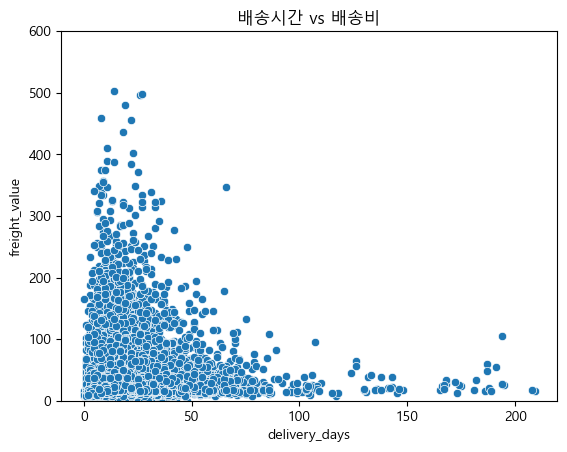

In [118]:
sns.scatterplot(data=_df, x='delivery_days', y='freight_value')
plt.ylim(0,600)
plt.title('배송시간 vs 배송비');

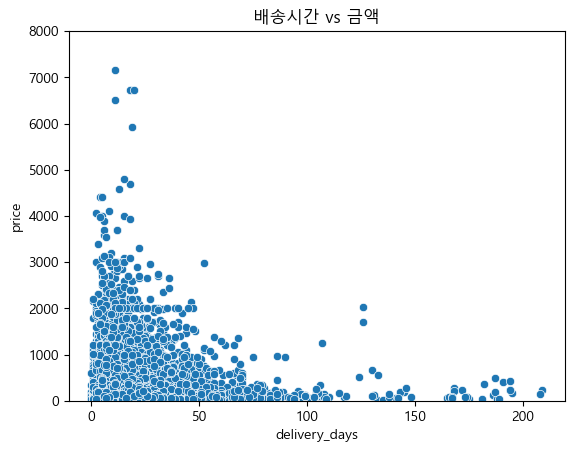

In [120]:
sns.scatterplot(data=_df, x='delivery_days', y='price')
plt.ylim(0,8000)
plt.title('배송시간 vs 금액');

In [123]:
products[['product_id','product_category_name']]

,product_id,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria
1,3aa071139cb16b67ca9e5dea641aaa2f,artes
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer
3,cef67bcfe19066a932b7673e239eb23d,bebes
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas
...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios


In [124]:
order_item[['product_id','price']]

,product_id,price
0,4244733e06e7ecb4970a6e2683c13e61,58.90
1,e5f2d52b802189ee658865ca93d83a8f,239.90
2,c777355d18b72b67abbeef9df44fd0fd,199.00
3,7634da152a4610f1595efa32f14722fc,12.99
4,ac6c3623068f30de03045865e4e10089,199.90
...,...,...
112645,4aa6014eceb682077f9dc4bffebc05b0,299.99
112646,32e07fd915822b0765e448c4dd74c828,350.00
112647,72a30483855e2eafc67aee5dc2560482,99.90
112648,9c422a519119dcad7575db5af1ba540e,55.99


In [125]:
_df=order_item[['product_id','price']].merge(products[['product_id','product_category_name']],on='product_id')
_df.head()

,product_id,price,product_category_name
0,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff
1,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop
2,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao
3,7634da152a4610f1595efa32f14722fc,12.99,perfumaria
4,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim


In [127]:
top10=_df.groupby('product_category_name').agg({'price':'sum'}).sort_values('price',ascending=False).head(10)
top10.rename(product_category_name_dict)

,price
product_category_name,
health_beauty,1258681.34
watches_gifts,1205005.68
bed_bath_table,1036988.68
sports_leisure,988048.97
computers_accessories,911954.32
furniture_decor,729762.49
cool_stuff,635290.85
housewares,632248.66
auto,592720.11


In [128]:
top10.price.sum()/_df.groupby('product_category_name').agg({'price':'sum'}).price.sum()

0.6319630959261215

- health_beauty, watches_gifts, bed_bath_table 제품군의 판매 비중이 높게 나타남
- 제품카테고리 상위 10개가 전체 매출의 63%를 차지하여 매출이 특정 품목에 집중되는 경향

In [129]:
bottom10=_df.groupby('product_category_name').agg({'price':'sum'}).sort_values('price').head(10)
bottom10.rename(product_category_name_dict)

,price
product_category_name,
security_and_services,283.29
fashion_childrens_clothes,569.85
cds_dvds_musicals,730.00
home_comfort_2,760.27
flowers,1110.04
pc_gamer,1545.95
diapers_and_hygiene,1567.59
arts_and_craftmanship,1814.01
la_cuisine,2054.99


In [130]:
bottom10.price.sum()/_df.groupby('product_category_name').agg({'price':'sum'}).price.sum()

0.0009361317107515599

- 제품 카테고리 하위 10개는 전체 매출의 약 0.09%에 불과함

In [132]:
orders.order_purchase_timestamp.min(),orders.order_purchase_timestamp.max()

(Timestamp('2016-09-04 21:15:19'), Timestamp('2018-10-17 17:30:18'))

In [133]:
orders[orders.order_purchase_timestamp.dt.year == 2016]

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delay_days,delivery_days
324,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,NaT,2016-12-09,NaN,NaN
378,cbbb524a0e1646aa6cf7a3c0bbe517ad,dacb079d55ffb1d3955c5d923df3ebb7,delivered,2016-10-05 07:31:49,2016-10-16 14:36:00,2016-12-07,9.0,11.0
699,ac2b7c522d811acba0aa270ed3e112e4,ef21aebbb093a6db29ccc6aa0b89c347,delivered,2016-10-05 15:08:00,2016-10-13 15:44:27,2016-11-29,-16.0,8.0
1384,7033745709b7cf1bac7d2533663592de,7f0ca17bb33b230b47459437cf0682c7,delivered,2016-10-04 14:13:22,2016-10-11 14:46:49,2016-11-30,-19.0,7.0
1449,5cd498954e2b37d71b315166809b4bd7,ff1a56726b7ea149c7423865609cc0c8,delivered,2016-10-07 00:54:40,2016-10-27 17:32:07,2016-12-01,26.0,20.0
...,...,...,...,...,...,...,...,...
98322,6e0d2539e48e84296bae6290de41058c,1fc56719b52f82c03caddc5faf531fbb,delivered,2016-10-04 19:41:52,2016-11-17 09:23:50,2016-11-30,-13.0,43.0
98484,9d664ec86be69d869bb6870294c4fdd8,0a9ee4d9030acbe428769c79d0c4da69,delivered,2016-10-08 15:02:10,2016-10-31 11:35:45,2016-12-12,19.0,22.0
99035,7e2dddf174cc4d2768bf39c43ab2bd7a,accfbaa1f092fdf6db1d8fcdad351b50,delivered,2016-10-09 15:10:41,2016-11-10 09:27:42,2016-12-02,8.0,31.0
99248,e439ced3d48f1a77f6ecc029cc946a6f,e9c6723e04c4e53e7e9c3afe383f3866,delivered,2016-10-07 22:35:59,2016-10-25 21:15:45,2016-12-01,24.0,17.0


In [136]:
left=orders[['order_id','order_purchase_timestamp']]
left.head()

,order_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39


In [137]:
right=order_item.groupby('order_id').agg({'price':'sum'})
right.head()

,price
order_id,
00010242fe8c5a6d1ba2dd792cb16214,58.90
00018f77f2f0320c557190d7a144bdd3,239.90
000229ec398224ef6ca0657da4fc703e,199.00
00024acbcdf0a6daa1e931b038114c75,12.99
00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [138]:
_df=left.merge(right,on='order_id')\
.assign(
    day=lambda df:df.order_purchase_timestamp.dt.date,
    month=lambda df:df.order_purchase_timestamp.dt.strftime('%Y-%m')
)
_df.head()

,order_id,order_purchase_timestamp,price,day,month
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,2017-10-02,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70,2018-07-24,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90,2018-08-08,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,2017-11-18,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,2018-02-13,2018-02


In [139]:
day_price=_df.groupby('day').agg({'price':'sum'}).iloc[:-1]
day_price

,price
day,
2016-09-04,72.89
2016-09-05,59.50
2016-09-15,134.97
2016-10-02,100.00
2016-10-03,441.98
...,...
2018-08-25,10599.41
2018-08-26,8070.71
2018-08-27,5345.91


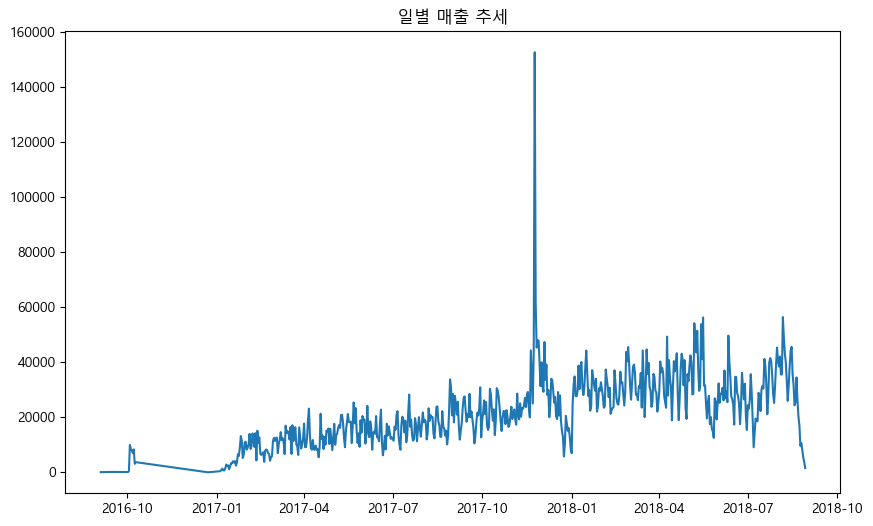

In [140]:
plt.figure(figsize=(10,6))
plt.plot(day_price.index,day_price.price)
plt.title('일별 매출 추세');

- 전체적으로 매출이 증가하는 흐름을 보이며, 중간에 특정 날짜에 급격한 매출 상승이 발생

In [141]:
day_price.describe()

,price
count,615.000000
mean,22098.947187
std,12574.446867
min,10.900000
25%,13046.200000
50%,20549.430000
75%,29595.065000
max,152653.740000


In [142]:
day_price[day_price.price==152653.740000]

,price
day,
2017-11-24,152653.74


In [144]:
_df[_df.day == pd.to_datetime('2017-11-24').date()].shape[0]

1166

In [147]:
_df.groupby('day').agg({'day':'count'}).rename({'day':'count'},axis=1).sort_values('count',ascending=False).head()

,count
day,
2017-11-24,1166
2017-11-25,498
2017-11-27,400
2017-11-26,388
2017-11-28,376


- 2017년 11월 24일(블랙프라이데이)에 거래량이 급등하여 매출 역시 큰 폭으로 상승한 것으로 나타남
- 반면, 2016년 9월 ~ 12월 데이터는 테스트용 샘플로, 같은 11월 기간임에도 블랙프라이데이의 효과에 따른 거래 급등 현상은 관찰되지 않음

In [148]:
query='''
SELECT *
FROM ORDER_REVIEWS
'''

In [149]:
order_reviews=pd.read_sql(query,conn)
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,None,None,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,None,None,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,None,None,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,None,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,None,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [150]:
order_reviews['review_score'].value_counts()

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

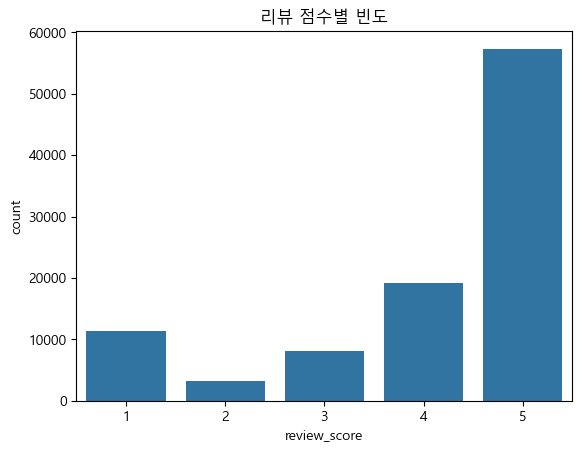

In [151]:
sns.countplot(data=order_reviews,x='review_score')
plt.title('리뷰 점수별 빈도');

- 4,5점대 높은 리뷰가 다수를 차지하지만, 동시에 1점대의 낮은 리뷰도 상당히 존재함

In [152]:
(order_reviews['review_score'] == 1).sum() 

11424

In [153]:
(order_reviews['review_score'] == 2).sum()

3151

In [154]:
((order_reviews['review_score'] == 1) | (order_reviews['review_score'] == 2)).mean()

0.14688986535515602

- 전체 리뷰점수 중 1,2점대의 낮은 리뷰 비율이 약 15%에 달함
- 이는 전반적으로 고객 만족도가 양호하나, 일부 주문에서 불만족 사례가 존재함을 알 수 있음

In [156]:
order_reviews[['review_score','review_comment_message']].head()

,review_score,review_comment_message
0,4,None
1,5,None
2,5,None
3,5,Recebi bem antes do prazo estipulado.
4,5,Parabéns lojas lannister adorei comprar pela I...


In [159]:
low = order_reviews[order_reviews.review_score<=2].review_comment_message.dropna()
low

16       GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...
19                                                 Péssimo
29                     Não gostei ! Comprei gato por lebre
32       Sempre compro pela Internet e a entrega ocorre...
39                            Nada de chegar o meu pedido.
                               ...                        
99155    Eu recebi o seguinte email e preciso saber com...
99169    Boa tarde. \r\nNão recebo todos os produtos fa...
99200    Foto muito diferente principalmente a graninha...
99203    Tive um problema na entrega em que o correio c...
99223    meu produto chegou e ja tenho que devolver, po...
Name: review_comment_message, Length: 10890, dtype: object

In [160]:
low_words = ' '.join(low).split()

In [161]:
from collections import Counter

In [162]:
Counter(low_words).most_common(20)

[('o', 7053),
 ('e', 5964),
 ('não', 5581),
 ('de', 4740),
 ('a', 4366),
 ('produto', 4273),
 ('que', 3797),
 ('recebi', 2487),
 ('do', 2375),
 ('com', 2165),
 ('um', 2067),
 ('foi', 1763),
 ('O', 1572),
 ('no', 1565),
 ('para', 1556),
 ('da', 1458),
 ('Não', 1456),
 ('veio', 1361),
 ('uma', 1339),
 ('é', 1339)]

'não', 'Não' : '아니다', '하지 않았다'를 나타내는 부정의 표현

'produto' : '상품', '제품'

'recebi' / 'veio' / 'foi' / 'é' : '받았다' / '왔다' / '되었다' / '이다'

- 리뷰 점수가 1,2점인 리뷰들에서 가장 많이 등장한 키워드는 전반적으로 상품이 늦게 왔다 / 안 왔다 / 문제가 있다 와 같은 불만 중심의 표현이 많이 포함되있음
- 이는 배송 지연 및 품질 관련 이슈가 주요 불만 요인임을 나타냄